In [1]:
!apt-get update
!apt-get install -y libgl1-mesa-glx
!pip install face_recognition
!pip install wikipedia
!pip install nltk
!pip install opencv-python

import os
import pickle
import face_recognition
import cv2
import numpy as np
import wikipedia
import re
import requests
from bs4 import BeautifulSoup
import nltk
from nltk.tokenize import sent_tokenize
import threading
import time

nltk.download('punkt')

Get:1 http://deb.debian.org/debian bullseye InRelease [116 kB]
Get:2 http://deb.debian.org/debian-security bullseye-security InRelease [27.2 kB]
Get:3 http://deb.debian.org/debian bullseye-updates InRelease [44.1 kB]
Get:4 http://deb.debian.org/debian bullseye/main amd64 Packages [8,066 kB]
Get:5 http://deb.debian.org/debian-security bullseye-security/main amd64 Packages [360 kB]
Get:6 http://deb.debian.org/debian bullseye-updates/main amd64 Packages [18.8 kB]
Fetched 8,632 kB in 1s (7,779 kB/s)




The following additional packages will be installed:
  libdrm-amdgpu1 libdrm-common libdrm-intel1 libdrm-nouveau2 libdrm-radeon1
  libdrm2 libgl1 libgl1-mesa-dri libglapi-mesa libglvnd0 libglx-mesa0 libglx0
  libllvm11 libpciaccess0 libsensors-config libsensors5 libvulkan1
  libwayland-client0 libx11-xcb1 libxcb-dri2-0 libxcb-dri3-0 libxcb-glx0
  libxcb-present0 libxcb-randr0 libxcb-sync1 libxcb-xfixes0 libxshmfence1
  libxxf86vm1 libz3-4 mesa-vulkan-drivers
Suggested packages:
  pciutils l

True

In [2]:
def load_image(image_path):
    image = face_recognition.load_image_file(image_path)
    print(f"Loaded image dtype: {image.dtype}, shape: {image.shape}")
    return image

In [3]:
def get_face_encodings(image):
    face_locations = face_recognition.face_locations(image, model="hog")
    return face_recognition.face_encodings(image, face_locations)

In [4]:
def build_encoding_database(dataset_path, encoding_file='celebrity_encodings.pkl'):
    encoding_path = os.path.join(dataset_path, encoding_file)
    if os.path.exists(encoding_path):
        with open(encoding_path, 'rb') as f:
            print("Loaded existing encodings.")
            return pickle.load(f)

    print("Encoding file not found. Creating it now...")
    encoding_db = {}
    for person in os.listdir(dataset_path):
        person_folder = os.path.join(dataset_path, person)
        if not os.path.isdir(person_folder):
            continue

        for img_name in os.listdir(person_folder):
            img_path = os.path.join(person_folder, img_name)
            try:
                image = face_recognition.load_image_file(img_path)
                encodings = face_recognition.face_encodings(image)
                if encodings:
                    encoding_db[person] = encodings[0]
                    break
            except Exception as e:
                print(f"Error processing {img_path}: {e}")

    with open(encoding_path, 'wb') as f:
        pickle.dump(encoding_db, f)
    print("Encodings saved.")
    return encoding_db

In [5]:
def identify_celebrity(face_encoding, database):
    names = list(database.keys())
    encodings = list(database.values())
    encodings = [e for e in encodings if isinstance(e, np.ndarray) and e.shape == (128,)]

    if not encodings:
        print("No valid encodings found in the database.")
        return "Unknown"

    distances = face_recognition.face_distance(encodings, face_encoding)
    if len(distances) == 0:
        print("No distances computed.")
        return "Unknown"

    best_match_index = np.argmin(distances)
    if distances[best_match_index] < 0.8:  # Add threshold for confidence
        return names[best_match_index]
    else:
        print(f"Low confidence match ({distances[best_match_index]:.2f})")
        return "Unknown"

In [6]:
def get_celebrity_summary(name):
    try:
        name_for_search = name.replace("_", " ")
        print(f"Searching Wikipedia for: {name_for_search}")
        
        # Try direct page lookup first
        try:
            page = wikipedia.page(name_for_search, auto_suggest=False)
            return page.title, page.content, page.url
        except wikipedia.exceptions.PageError:
            pass  # Fall through to search method
        except wikipedia.exceptions.DisambiguationError as e:
            # Try to find the exact match in disambiguation options
            for option in e.options:
                if option.lower() == name_for_search.lower():
                    page = wikipedia.page(option)
                    return page.title, page.content, page.url

        # If direct lookup fails, use search with improved filtering
        results = wikipedia.search(name_for_search)
        filtered_results = [
            r for r in results 
            if not any(bad in r.lower() 
                     for bad in ["filmography", "discography", "list of", " incident"])
        ]

        # Prioritize exact match or shortest result (most likely main page)
        filtered_results.sort(key=lambda x: (x.lower() != name_for_search.lower(), len(x)))
        
        for result in filtered_results:
            try:
                page = wikipedia.page(result, auto_suggest=False)
                # Secondary check for unwanted pages
                if any(bad in page.title.lower() 
                     for bad in ["filmography", "discography", "list of"]):
                    continue
                return page.title, page.content, page.url
            except (wikipedia.exceptions.PageError, 
                    wikipedia.exceptions.DisambiguationError):
                continue

        return "", "", ""
    except Exception as e:
        print(f"Error in Wikipedia search: {e}")
        return "", "", ""

In [7]:
def summarize_bio(name, content):
    """Extract general biographical information based on content analysis"""
    bio = []
    
    # Extract occupation
    occupation_pattern = r"(?i)is an? (?:American|British|Canadian|Australian|[A-Za-z]+) ((?:[A-Za-z]+(?:, | and )?)+)"
    occupation_match = re.search(occupation_pattern, content[:1000])
    if occupation_match:
        bio.append(f"Occupation: {occupation_match.group(1).strip()}")
    
    # Extract birth date
    birth_date_pattern = r"(?i)born (?:on )?([A-Za-z]+ \d+, \d{4})"
    birth_match = re.search(birth_date_pattern, content[:1000])
    if birth_match:
        bio.append(f"Born: {birth_match.group(1)}")
    
    # Extract nationality
    nationality_pattern = r"(?i)is an? ([A-Za-z]+) (actor|actress|singer|rapper|producer|director|writer|athlete|politician)"
    nationality_match = re.search(nationality_pattern, content[:1000])
    if nationality_match:
        bio.append(f"Nationality: {nationality_match.group(1)}")
    
    # Extract notable works/awards
    notable_works = []
    
    # Look for award mentions
    for award in ["Academy Award", "Oscar", "Grammy", "Emmy", "Golden Globe"]:
        if re.search(f"(?i){re.escape(award)}", content):
            notable_works.append(f"{award} winner/nominee")
    
    # Extract famous for
    famous_for_patterns = [
        r"(?i)known for (?:her|his|their) ((?:role|work) (?:in|on) [^\.]+)",
        r"(?i)famous for ([^\.]+)",
        r"(?i)best known for ([^\.]+)"
    ]
    
    for pattern in famous_for_patterns:
        famous_match = re.search(pattern, content)
        if famous_match:
            bio.append(f"Famous for: {famous_match.group(1).strip()}")
            break
    
    if notable_works:
        bio.append(f"Awards/Recognition: {', '.join(notable_works)}")
    
    return "\n".join(bio) if bio else f"No key facts extracted for {name}."

In [8]:
def extract_controversy_keywords():
    """Return a comprehensive list of controversy-related keywords"""
    return [
        # General controversy terms
        "controversy", "controversial", "scandal", "criticism", "backlash",
        "outcry", "protest", "uproar", "outrage", "condemn", "criticized",
        "allegations", "alleged", "accused", "apologized", "apology",
        
        # Legal issues
        "legal issues", "lawsuit", "sued", "court", "trial", "case", "settlement",
        "conviction", "arrested", "charged", "indicted", "investigation",
        
        # Personal scandals
        "affair", "divorce", "cheating", "infidelity", "addiction", "substance abuse",
        "rehab", "bankruptcy", "assault", "domestic", "violence", "abuse",
        
        # Professional controversies
        "fired", "cancelled", "dropped", "dispute", "feud", "banned", "prohibited",
        "blacklisted", "boycott", "declined", "rejected",
        
        # Social media/public relations
        "deleted", "offensive", "inappropriate", "insensitive", "slammed",
        "backlash", "negative", "viral", "twitter", "instagram", "comment",
        
        # Ethical issues
        "ethics", "misconduct", "unethical", "inappropriate", "harassment",
        "discrimination", "racist", "sexist", "homophobic", "xenophobic",
        "misogynistic", "inappropriate behavior"
    ]

In [9]:
def refine_controversy_list(controversies):
    """
    Refines the controversy list by grouping related topics and removing redundancy.
    """
    grouped_controversies = {}
    for controversy in controversies:
        # Determine the main subject of the controversy using keywords
        subject = None
        for keyword in extract_controversy_keywords():
            if keyword in controversy.lower():
                subject = keyword.capitalize()
                break

        # Group controversies by subject
        if subject:
            if subject not in grouped_controversies:
                grouped_controversies[subject] = []
            grouped_controversies[subject].append(controversy)
        else:
            # If no clear subject, add to 'Miscellaneous'
            if "Miscellaneous" not in grouped_controversies:
                grouped_controversies["Miscellaneous"] = []
            grouped_controversies["Miscellaneous"].append(controversy)

    # Format the refined list
    refined_list = []
    for subject, entries in grouped_controversies.items():
        # Combine related entries into a single bullet point
        combined_entry = " ".join(entries[:3])  # Limit to 3 entries per subject
        refined_list.append(f"{subject}: {combined_entry}")

    return "\n".join(refined_list)

In [10]:
def summarize_controversies(controversies):
    """
    Summarizes controversies into concise bullet points with unique subjects.
    Each bullet point describes the controversy briefly and avoids redundancy.
    """
    summarized_controversies = []
    seen_subjects = set()

    for controversy in controversies:
        # Extract a brief summary of the controversy
        sentences = sent_tokenize(controversy["content"])
        if not sentences:
            continue

        # Use the first sentence as a summary
        summary = sentences[0]
        summary = re.sub(r"\(.*?\)", "", summary)  # Remove parenthesis
        summary = re.sub(r"\s+", " ", summary).strip(" .-")  # Clean spaces

        # Check for duplicate or similar subjects
        subject_keywords = ["divorce", "criticism", "controversy", "scandal", "feud", "lawsuit"]
        subject = next((kw.capitalize() for kw in subject_keywords if kw in summary.lower()), "Miscellaneous")
        
        if subject not in seen_subjects:
            summarized_controversies.append(f"• {subject}: {summary}.")
            seen_subjects.add(subject)

    return "\n".join(summarized_controversies[:5])  # Limit to 5 key points

In [11]:
def extract_controversies_improved(title, full_content, wiki_url):
    """
    Improved function to extract controversies from Wikipedia content and summarize them.
    """
    controversies = []
    controversy_keywords = extract_controversy_keywords()

    try:
        response = requests.get(wiki_url)
        soup = BeautifulSoup(response.content, "html.parser")

        headings = soup.find_all(['h2', 'h3', 'h4'])
        for heading in headings:
            heading_text = heading.get_text().lower()
            if "contents" in heading_text or "references" in heading_text or "notes" in heading_text:
                continue

            if any(keyword in heading_text for keyword in controversy_keywords):
                section_title = heading.get_text().replace("[edit]", "").strip()
                content = []
                current = heading.next_sibling
                while current and not (hasattr(current, 'name') and current.name in ['h2', 'h3', 'h4']):
                    if hasattr(current, 'name') and current.name in ['p', 'li']:
                        content.append(current.get_text().strip())
                    current = current.next_sibling
                if content:
                    controversies.append({
                        "section": section_title,
                        "content": " ".join(content)
                    })

        # Extract controversy-related sentences from full content
        sentences = sent_tokenize(full_content)
        potential_controversy_sentences = []
        for sentence in sentences:
            if len(sentence.split()) < 10:  # Skip short sentences
                continue

            sentence_lower = sentence.lower()
            if any(keyword in sentence_lower for keyword in controversy_keywords):
                name_parts = title.lower().split()
                if any(part in sentence_lower for part in name_parts) or \
                   any(pronoun in sentence_lower.split() for pronoun in ["he", "she", "they", "his", "her", "their"]):
                    potential_controversy_sentences.append(sentence)

        if potential_controversy_sentences:
            current_group = [potential_controversy_sentences[0]]
            for i in range(1, len(potential_controversy_sentences)):
                current_sentence = potential_controversy_sentences[i]
                prev_sentence = potential_controversy_sentences[i - 1]
                if full_content.find(current_sentence) - full_content.find(prev_sentence) < 500:
                    current_group.append(current_sentence)
                else:
                    if len(current_group) >= 2:
                        controversies.append({
                            "section": "Controversy Mention",
                            "content": " ".join(current_group)
                        })
                    current_group = [current_sentence]

            if len(current_group) >= 2:
                controversies.append({
                    "section": "Controversy Mention",
                    "content": " ".join(current_group)
                })

    except Exception as e:
        controversies.append({
            "section": "Error",
            "content": f"Error extracting controversies: {str(e)}"
        })

    unique_controversies = list({c["content"]: c for c in controversies}.values())  # Remove duplicates
    return summarize_controversies(unique_controversies)

In [12]:
def shorten_controversy_text(text):
    """
    Tokenize the paragraph into sentences and pick the most relevant ones.
    Clean up unnecessary text like parenthesis and extra spaces.
    """
    sentences = sent_tokenize(text)
    relevant_sentences = []

    for sentence in sentences:
        # Check if sentence contains name/pronoun and controversy term
        lowered = sentence.lower()
        if any(word in lowered for word in ["smith", "he", "his", "will"]) and any(
            kw in lowered for kw in extract_controversy_keywords()
        ):
            bullet = re.sub(r"\(.*?\)", "", sentence)  # Remove parenthesis
            bullet = re.sub(r"\s+", " ", bullet).strip(" .-")  # Clean spaces
            relevant_sentences.append(f"{bullet}.")

    # Return formatted bullet points or fallback to first few sentences
    if relevant_sentences:
        return "\n".join(relevant_sentences[:5])  # Limit to 5 key points
    else:
        fallback = re.sub(r"\s+", " ", sentences[0]).strip(" .-")
        return f"{fallback}."

In [13]:
def celebrity_recognition_system(image_path, dataset_path):
    image = load_image(image_path)
    face_encodings = get_face_encodings(image)

    if not face_encodings:
        print("No faces detected in the image.")
        return

    face_encoding = face_encodings[0]
    print(f"\nTest image encoding shape: {face_encoding.shape}")

    database = build_encoding_database(dataset_path)
    print(f"\nComparing to {len(database)} known encodings...")

    celebrity_name = identify_celebrity(face_encoding, database)
    print(f"\nIdentified: {celebrity_name}")

    if celebrity_name == "Unknown":
        print("Face not recognized in dataset. Skipping Wikipedia search.")
        return

    title, full_content, wiki_url = get_celebrity_summary(celebrity_name)
    
    if not title or not full_content:
        print("Could not find Wikipedia information for this celebrity.")
        return

    print(f"\nFound Wikipedia page: {title}")
    
    print("\nKey Bio Facts:")
    print(summarize_bio(celebrity_name, full_content))

    print("\nControversies and Noteworthy Incidents:")
    controversies = extract_controversies_improved(title, full_content, wiki_url)
    print(controversies)

    print("\n📈 Government Trades Summary:")
    print(search_historical_trades_for_official(celebrity_name.replace("_", " ")))

In [14]:
def search_historical_trades_for_official(official_name):
    """
    Pulls FULL historical congressional trades and filters them by official name.
    """
    QUIVER_API_KEY = "6978a757d4a2ba76146c61f749a50807d75adbb3"
    headers = {"Authorization": f"Bearer {QUIVER_API_KEY}"}
    url = "https://api.quiverquant.com/beta/bulk/congresstrading"

    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        trades = response.json()

        # Filter trades for the specific official
        filtered = [t for t in trades if official_name.lower() in t.get("Representative", "").lower()]
        
        if not filtered:
            return f"No historical trades found for {official_name}."

        return format_multiple_trades(filtered)

    except requests.exceptions.RequestException as e:
        return f"Error connecting to the API: {e}"
    except Exception as e:
        return f"Unexpected error: {e}"

In [15]:
def format_multiple_trades(trades):
    """
    Format multiple trades into a clean bullet point list.
    """
    formatted = []
    for trade in trades:
        ticker = trade.get("Ticker", "N/A")
        amount_raw = trade.get("Amount", 0)
        try:
            amount_num = int(amount_raw)
            amount = f"${amount_num:,.0f}+"
        except:
            amount = str(amount_raw)
        date = trade.get("TransactionDate", "N/A") 
        type_ = trade.get("Transaction", "N/A")
        formatted.append(f"{type_} {ticker} worth {amount} on {date}.")
    return "\n".join(formatted)

In [16]:
    test_image = "/work/MVQ4HTMGEBGOB7TXMUAB2BBB5I.jpg"
    dataset_folder = "government_officials_dataset"
    celebrity_recognition_system(test_image, dataset_path=dataset_folder) 

Loaded image dtype: uint8, shape: (3554, 4738, 3)

Test image encoding shape: (128,)
Loaded existing encodings.

Comparing to 30 known encodings...

Identified: Nancy_Pelosi
Searching Wikipedia for: Nancy Pelosi

Found Wikipedia page: Nancy Pelosi

Key Bio Facts:
Occupation: politician
Born: March 26, 1940
Nationality: American

Controversies and Noteworthy Incidents:
• Miscellaneous: In May 2006, with an eye on the upcoming midterm elections—which offered the possibility of Democrats taking back control of the House for the first time since 1994—Pelosi told colleagues that, while the Democrats would conduct vigorous oversight of Bush administration policy, an impeachment investigation was "off the table".
• Scandal: She added that Republicans were engaged in a "cover-up campaign" to protect Trump: "House Republicans' pattern of obstruction and cover-up to hide the truth about the Trump-Russia scandal represents a threat to our intelligence and our national security.
• Criticism: == Pu

# Live-Stream Integration

In [19]:
TEXT_COLOR = (0, 255, 0)        # BGR  →  Lime-green
TEXT_THICK = 1                  

def _fetch_metadata(name, cache, lock):
    """
    Helper thread: pulls Wikipedia bio, controversies, and QuiverQuant trades
    once per identity and stores them in a shared cache.
    """
    try:
        title, full_content, wiki_url = get_celebrity_summary(name)
        bio         = summarize_bio(name, full_content)
        controversies = extract_controversies_improved(title, full_content, wiki_url)
        trades      = search_historical_trades_for_official(name.replace("_", " "))
        with lock:
            cache[name] = (bio, controversies, trades)
    except Exception as e:
        with lock:
            cache[name] = (f"Metadata error: {e}", "", "")

In [22]:
def run_live_stream(dataset_path="government_officials_dataset",
                    detection_model="hog",
                    downscale=0.5):

    FONT_INFO   = 0.50
    FONT_LABEL  = 0.45
    LINE_H      = 20
    LEFT_PAD    = 10      # <-- distance from the *left* edge now

    print("Building / loading face encodings …")
    database     = build_encoding_database(dataset_path)
    meta_cache   = {}
    cache_lock   = threading.Lock()
    pending_meta = set()

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        raise RuntimeError("Could not open webcam.")

    print("Webcam stream started. Press 'q' to quit.")
    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                time.sleep(0.1)
                continue

            small     = cv2.resize(frame, (0, 0), fx=downscale, fy=downscale)
            rgb_small = cv2.cvtColor(small, cv2.COLOR_BGR2RGB)
            locs      = face_recognition.face_locations(rgb_small, model=detection_model)
            encs      = face_recognition.face_encodings(rgb_small, locs)

            names_seen = []

            for (t, r, b, l), enc in zip(locs, encs):
                name = identify_celebrity(enc, database)
                names_seen.append(name)

                # scale box back to full frame
                t, r, b, l = [int(v / downscale) for v in (t, r, b, l)]
                cv2.rectangle(frame, (l, t), (r, b), (255, 0, 0), 2)

                # label over head
                cv2.putText(frame, name.replace("_", " "),
                            (l, max(20, t - 8)),
                            cv2.FONT_HERSHEY_SIMPLEX, FONT_LABEL,
                            TEXT_COLOR, TEXT_THICK, cv2.LINE_AA)

                # fetch metadata once
                if name != "Unknown" and name not in meta_cache and name not in pending_meta:
                    pending_meta.add(name)
                    threading.Thread(target=_fetch_metadata,
                                     args=(name, meta_cache, cache_lock),
                                     daemon=True).start()

            # ---------- fixed overlay (top-left) ----------
            seen_unique = []
            [seen_unique.append(n) for n in names_seen if n not in seen_unique]

            overlay = []
            with cache_lock:
                for nm in seen_unique:
                    bio, contr, trade = meta_cache.get(nm, ("", "", ""))
                    block = [nm]
                    if bio:   block.append(bio.split("\n")[0])
                    if contr: block.append(contr.split("\n")[0])
                    if trade: block.append(trade.split("\n")[0])
                    block = [ln.replace("•", "-") for ln in block]
                    overlay.extend(block)
                    overlay.append("")

            start_x, start_y = LEFT_PAD, 25
            for i, txt in enumerate(overlay):
                if not txt:
                    continue
                y = start_y + i * LINE_H
                cv2.putText(frame, txt, (start_x, y),
                            cv2.FONT_HERSHEY_SIMPLEX, FONT_INFO,
                            (0, 0, 0), TEXT_THICK + 2, cv2.LINE_AA)   # outline
                cv2.putText(frame, txt, (start_x, y),
                            cv2.FONT_HERSHEY_SIMPLEX, FONT_INFO,
                            TEXT_COLOR, TEXT_THICK, cv2.LINE_AA)       # main text

            cv2.imshow("Live Politician Recognition", frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
    finally:
        cap.release()
        cv2.destroyAllWindows()
        print("Stream ended.")


In [31]:
    run_live_stream(dataset_path="government_officials_dataset",
                    detection_model="hog")   # or "cnn" if you have GPU

Building / loading face encodings …
Loaded existing encodings.
[ WARN:0@564.745] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@564.745] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range


RuntimeError: Could not open webcam.

# **** END OF CODE*****BELOW IS GRAPH CREATIONS

/tmp/ipykernel_68/3874063062.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(10), x='Image Count', y='Politician', palette='viridis')


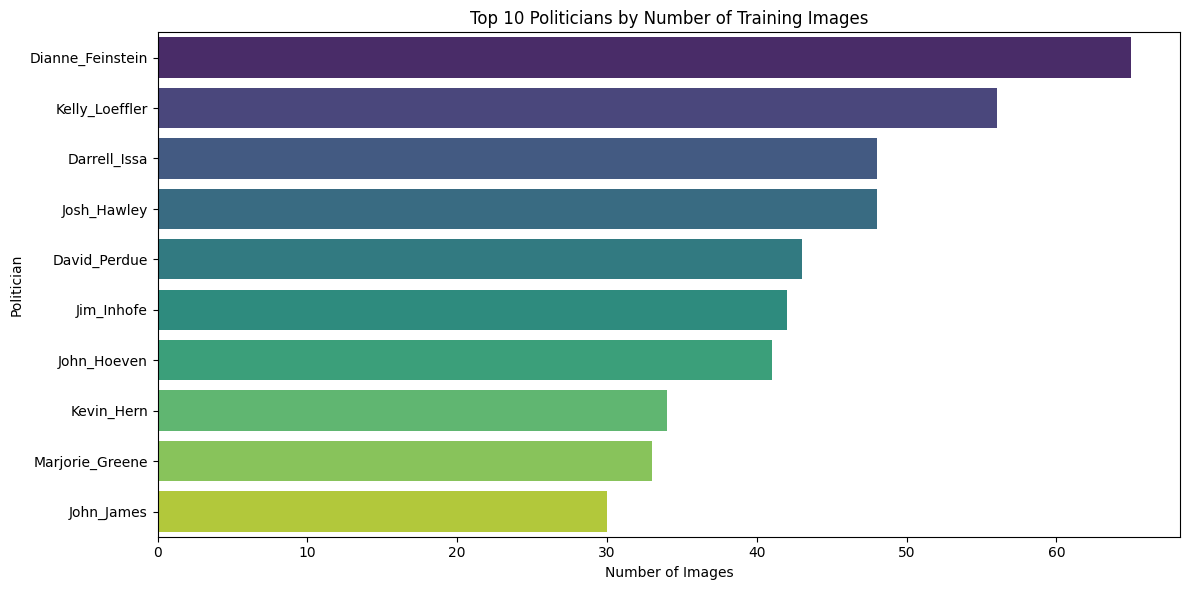

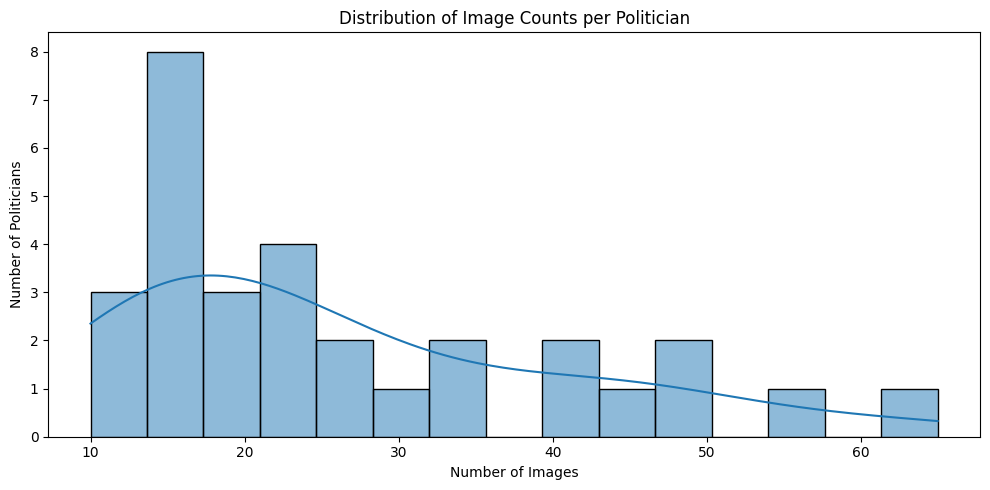

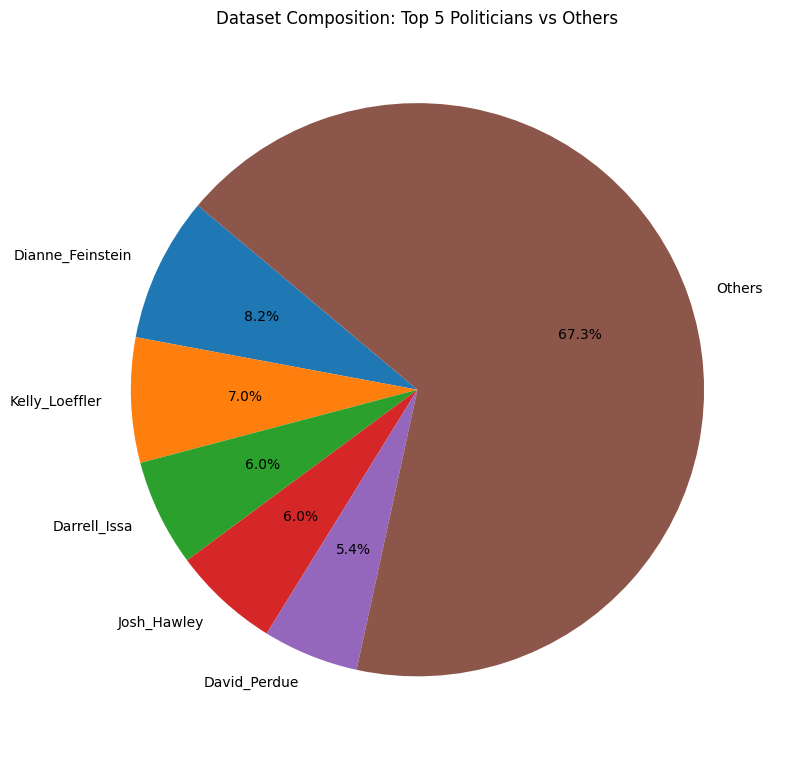


Summary Stats:
count    30.000000
mean     26.500000
std      14.535925
min      10.000000
25%      15.250000
50%      22.500000
75%      33.750000
max      65.000000
Name: Image Count, dtype: float64

Total Politicians: 30
Total Images: 795


In [61]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set your dataset path here
dataset_path = 'government_officials_dataset'

# Step 1: Scan the dataset directory and count images per politician
politician_image_counts = {}
for name in os.listdir(dataset_path):
    subdir = os.path.join(dataset_path, name)
    if os.path.isdir(subdir):
        images = [f for f in os.listdir(subdir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        politician_image_counts[name] = len(images)

# Convert to DataFrame
df = pd.DataFrame(politician_image_counts.items(), columns=['Politician', 'Image Count'])
df = df.sort_values(by='Image Count', ascending=False)

# Step 2: Plot top 10 politicians with the most images
plt.figure(figsize=(12, 6))
sns.barplot(data=df.head(10), x='Image Count', y='Politician', palette='viridis')
plt.title('Top 10 Politicians by Number of Training Images')
plt.xlabel('Number of Images')
plt.ylabel('Politician')
plt.tight_layout()
plt.show()

# Step 3: Histogram of image count distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Image Count'], bins=15, kde=True)
plt.title('Distribution of Image Counts per Politician')
plt.xlabel('Number of Images')
plt.ylabel('Number of Politicians')
plt.tight_layout()
plt.show()

# Step 4: Pie chart of top 5 vs others
top5 = df.head(5)
others = df['Image Count'].iloc[5:].sum()
labels = list(top5['Politician']) + ['Others']
sizes = list(top5['Image Count']) + [others]

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Dataset Composition: Top 5 Politicians vs Others')
plt.tight_layout()
plt.show()

# Step 5: Summary statistics
print("\nSummary Stats:")
print(df['Image Count'].describe())
print(f"\nTotal Politicians: {len(df)}")
print(f"Total Images: {df['Image Count'].sum()}")


### 1 Recognition Quality at a Glance
(Confusion-Matrix Heat-map)

Loaded existing encodings.
Loaded image dtype: uint8, shape: (183, 275, 3)
Loaded image dtype: uint8, shape: (3356, 2687, 3)
Loaded image dtype: uint8, shape: (225, 225, 3)
Loaded image dtype: uint8, shape: (455, 242, 3)
⚠️ No face detected in: test_dataset/SJ-test3.jpg
Loaded image dtype: uint8, shape: (399, 599, 3)
Loaded image dtype: uint8, shape: (275, 183, 3)
Loaded image dtype: uint8, shape: (275, 183, 3)
❌ Error processing test_dataset/actress-SJ-test.avif: cannot identify image file 'test_dataset/actress-SJ-test.avif'
Loaded image dtype: uint8, shape: (683, 1024, 3)
Loaded image dtype: uint8, shape: (2062, 1731, 3)
❌ Error processing test_dataset/fix_image_hardcore.py: cannot identify image file 'test_dataset/fix_image_hardcore.py'
Loaded image dtype: uint8, shape: (1137, 910, 3)
❌ Error processing test_dataset/simple_test.py: cannot identify image file 'test_dataset/simple_test.py'
❌ Error processing test_dataset/test.py: cannot identify image file 'test_dataset/test.py'
Loade

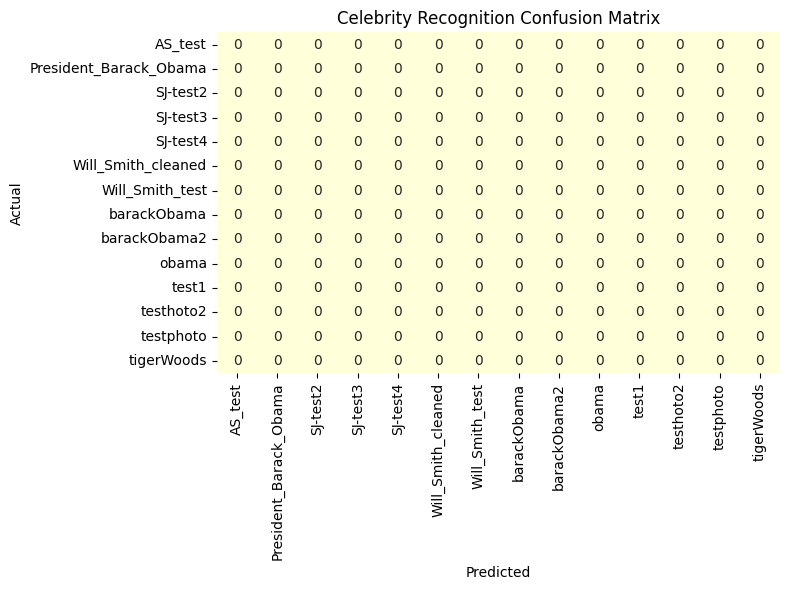

In [115]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

test_dataset_path = "test_dataset"
database = build_encoding_database("government_officials_dataset")

# Loop through each item (file or folder)
for entry in os.listdir(test_dataset_path):
    path = os.path.join(test_dataset_path, entry)

    if os.path.isdir(path):
        # Folder: multiple images per person
        celeb_name = entry
        for image_file in os.listdir(path):
            image_path = os.path.join(path, image_file)
            try:
                image = load_image(image_path)
                encodings = get_face_encodings(image)
                if encodings:
                    prediction = identify_celebrity(encodings[0], database)
                else:
                    prediction = "Unknown"
                    print(f"⚠️ No face detected in: {image_path}")
                y_true.append(celeb_name)
                y_pred.append(prediction)
            except Exception as e:
                print(f"❌ Error processing {image_path}: {e}")
    elif os.path.isfile(path):
        # File: single image, infer label from filename (e.g., tigerWoods.jpeg → tigerWoods)
        celeb_name = os.path.splitext(entry)[0]
        try:
            image = load_image(path)
            encodings = get_face_encodings(image)
            if encodings:
                prediction = identify_celebrity(encodings[0], database)
            else:
                prediction = "Unknown"
                print(f"⚠️ No face detected in: {path}")
            y_true.append(celeb_name)
            y_pred.append(prediction)
        except Exception as e:
            print(f"❌ Error processing {path}: {e}")

print("Number of samples processed:", len(y_true))
print("Unique true labels:", set(y_true))
print("Unique predicted labels:", set(y_pred))

# Plot confusion matrix if possible
if y_true and y_pred:
    cm = confusion_matrix(y_true, y_pred, labels=sorted(set(y_true)))
    df_cm = pd.DataFrame(cm, index=sorted(set(y_true)), columns=sorted(set(y_true)))
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Celebrity Recognition Confusion Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No valid predictions were made.")

### 2 How Tight Are the Face Embeddings?
(Match vs. Non-match Distance Distributions)

Encoding file not found. Creating it now...
✅ Austin_Scott: download (.jpg
✅ Austin_Scott: download (_1.jpg
✅ Austin_Scott: download (_2.jpg
✅ Austin_Scott: download (_3.jpg
✅ Austin_Scott: download.jpg
✅ Austin_Scott: download1.jpg
✅ Austin_Scott: images (1).jpg
✅ Austin_Scott: images (2).jpg
✅ Austin_Scott: images.jpg
✅ Austin_Scott: sddefault.jpg
✅ Bill_Hagerty: 36d9b391-6.webp
✅ Bill_Hagerty: download (.jpg
✅ Bill_Hagerty: download (_1.jpg
✅ Bill_Hagerty: download (_10.jpg
✅ Bill_Hagerty: download (_11.jpg
✅ Bill_Hagerty: download (_12.jpg
✅ Bill_Hagerty: download (_2.jpg
✅ Bill_Hagerty: download (_3.jpg
✅ Bill_Hagerty: download (_4.jpg
✅ Bill_Hagerty: download (_5.jpg
✅ Bill_Hagerty: download (_6.jpg
✅ Bill_Hagerty: download (_7.jpg
✅ Bill_Hagerty: download (_8.jpg
✅ Bill_Hagerty: download (_9.jpg
✅ Bill_Hagerty: download.jpg
✅ Brad_Schneider: download (.jpg
✅ Brad_Schneider: download (_1.jpg
✅ Brad_Schneider: download (_10.jpg
✅ Brad_Schneider: download (_2.jpg
✅ Brad_Schneider: 

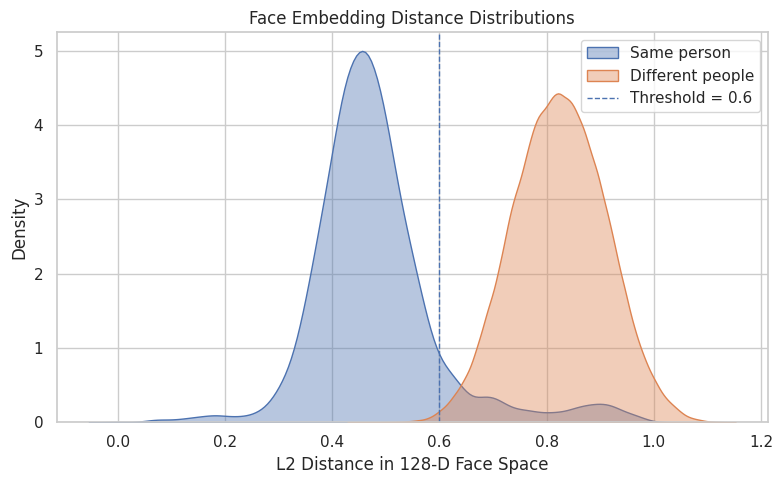

In [121]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import face_recognition
from itertools import combinations


def build_encoding_database(dataset_path, encoding_file='celebrity_encodings.pkl'):
    encoding_path = os.path.join(dataset_path, encoding_file)
    if os.path.exists(encoding_path):
        with open(encoding_path, 'rb') as f:
            print("✅ Loaded existing encodings.")
            return pickle.load(f)

    print("Encoding file not found. Creating it now...")
    encoding_db = {}

    for person in os.listdir(dataset_path):
        person_folder = os.path.join(dataset_path, person)
        if not os.path.isdir(person_folder):
            continue

        encodings = []
        for img_name in os.listdir(person_folder):
            img_path = os.path.join(person_folder, img_name)
            if not img_path.lower().endswith(('.jpg', '.jpeg', '.png', '.webp', '.bmp')):
                continue
            try:
                image = face_recognition.load_image_file(img_path)
                found_encodings = face_recognition.face_encodings(image)
                if found_encodings:
                    encodings.append(found_encodings[0])
                    print(f"✅ {person}: {img_name}")
                else:
                    print(f"⚠️ No face detected in {img_path}")
            except Exception as e:
                print(f"❌ Error processing {img_path}: {e}")

        if encodings:
            encoding_db[person] = encodings

    with open(encoding_path, 'wb') as f:
        pickle.dump(encoding_db, f)
    print("✅ Saved all encodings.")
    return encoding_db


def compute_face_distances(database):
    match_distances = []
    nonmatch_distances = []

    for name, encodings in database.items():
        if len(encodings) < 2:
            continue
        for a, b in combinations(encodings, 2):
            dist = np.linalg.norm(a - b)
            match_distances.append(dist)

    names = list(database.keys())
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            encs1 = database[names[i]]
            encs2 = database[names[j]]
            for e1 in encs1:
                for e2 in encs2:
                    dist = np.linalg.norm(e1 - e2)
                    nonmatch_distances.append(dist)

    return match_distances, nonmatch_distances


def plot_embedding_distances(match_distances, nonmatch_distances, threshold=0.6):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 5))
    sns.kdeplot(match_distances, label="Same person", fill=True, alpha=0.4)
    sns.kdeplot(nonmatch_distances, label="Different people", fill=True, alpha=0.4)
    plt.axvline(threshold, ls="--", lw=1, label=f"Threshold = {threshold}")
    plt.xlabel("L2 Distance in 128-D Face Space")
    plt.ylabel("Density")
    plt.title("Face Embedding Distance Distributions")
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    dataset_path = "government_officials_dataset"  # Adjust as needed
    encoding_db = build_encoding_database(dataset_path)

    for person, encs in encoding_db.items():
        print(f"{person}: {len(encs)} encodings")

    match_distances, nonmatch_distances = compute_face_distances(encoding_db)
    print(f"\n✅ Computed {len(match_distances)} same-person distances.")
    print(f"✅ Computed {len(nonmatch_distances)} different-person distances.")

    if match_distances and nonmatch_distances:
        plot_embedding_distances(match_distances, nonmatch_distances)
    else:
        print("❌ Not enough data to compute and visualize distances.")


### 3 Top-k Most Frequent Mis-IDs
(Horizontal Bar Chart)

In [82]:
from collections import Counter
import matplotlib.pyplot as plt

errors = [true for true, pred in zip(y_true, y_pred) if true != pred]
err_counts = Counter(errors).most_common(10)
names, counts = zip(*err_counts)

plt.figure(figsize=(6, 3.5))
plt.barh(names, counts)
plt.gca().invert_yaxis()
plt.xlabel("# Incorrect Predictions")
plt.title("Most-Misidentified Individuals (top-10)")
plt.tight_layout(); plt.show()


NameError: name 'y_true' is not defined

### 4 What Do People Get in Trouble For?
(Stacked Bar of Controversy Categories)

In [91]:
# Build a tall DataFrame: one row per (person, category) pair
df = pd.DataFrame(all_controversies)   # columns: ["Name","Category"]
pivot = df.pivot_table(index="Name", columns="Category", aggfunc=len, fill_value=0)

pivot.plot(kind="barh", stacked=True, figsize=(8, 5))
plt.xlabel("# Mentions"); plt.ylabel("")
plt.title("Controversy Mentions by Category")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()


NameError: name 'all_controversies' is not defined

### 5 Follow the Money: Trade Activity Over Time
(Timeline of Buys vs. Sells)

In [88]:
import pandas as pd, matplotlib.pyplot as plt

df_trades = pd.DataFrame(filtered)         # output of format_multiple_trades → list[dict]
df_trades["Date"] = pd.to_datetime(df_trades["TransactionDate"])
df_trades["Shares"] = pd.to_numeric(df_trades["Amount"], errors="coerce").fillna(0)

plt.figure(figsize=(9, 4))
for ttype, ls in [("Purchase", "-"), ("Sale/Distribution", "--")]:
    subset = df_trades[df_trades["Transaction"] == ttype]
    subset.groupby("Date")["Shares"].sum().cumsum().plot(ls=ls, label=ttype)

plt.ylabel("Cumulative $ Value (approx.)"); plt.xlabel("Date")
plt.title(f"Cumulative Trades — {official_name}")
plt.legend(); plt.tight_layout(); plt.show()


NameError: name 'filtered' is not defined

### 6 Heat-map of Congressional Trading Intensity
(Month × Official)

In [85]:
df_all = pd.DataFrame(all_trades)          # every row from bulk endpoint
df_all["Month"] = pd.to_datetime(df_all["TransactionDate"]).dt.to_period("M").astype(str)
heat = df_all.groupby(["Representative", "Month"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 0.4*heat.shape[0]))
sns.heatmap(heat, cmap="Blues", cbar_kws={"label":"# Trades"})
plt.xlabel("Month"); plt.ylabel("")
plt.title("Congressional Trade Frequency Heat-map")
plt.tight_layout(); plt.show()


NameError: name 'all_trades' is not defined

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c157ff68-0c3d-4a38-b7d7-bae220938a25' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>